<a href="https://colab.research.google.com/github/ZehanQin/ECON5200-Applied-Data-Analytics-in-Econ/blob/main/Assignment%205/Econ_5200_Assignment_5_The_Sovereign_Risk_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import wbgapi as wb

import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import lasso_path
from sklearn.linear_model import LassoCV

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

In [3]:
np.random.seed(42)

In [4]:
INDICATORS = {

    'NY.GDP.PCAP.KD.ZG': 'gdp_growth_pc',


    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'BX.KLT.DINV.WD.GD.ZS': 'fdi_inflows_pct_gdp',
    'TM.TAX.MRCH.SM.AR.ZS': 'tariff_rate_avg',
    'BX.GSR.ROYL.CD':    'royalties_receipts',


    'FP.CPI.TOTL.ZG':    'inflation_cpi',
    'GC.DOD.TOTL.GD.ZS': 'govt_debt_pct_gdp',
    'GC.XPN.TOTL.GD.ZS': 'govt_expenditure_pct_gdp',
    'BN.CAB.XOKA.GD.ZS': 'current_account_pct_gdp',
    'FR.INR.RINR':       'real_interest_rate',
    'PA.NUS.FCRF':       'exchange_rate_official',


    'SE.SEC.ENRR':       'secondary_enrollment_gross',
    'SE.TER.ENRR':       'tertiary_enrollment_gross',
    'SE.ADT.LITR.ZS':    'adult_literacy_rate',
    'SE.XPD.TOTL.GD.ZS': 'education_expenditure_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',


    'IT.NET.USER.ZS':    'internet_users_pct',
    'IT.CEL.SETS.P2':    'mobile_subscriptions_per100',
    'EG.ELC.ACCS.ZS':    'electricity_access_pct',
    'IS.ROD.PAVE.ZS':    'paved_roads_pct',


    'SP.DYN.LE00.IN':    'life_expectancy',
    'SH.DYN.MORT':       'infant_mortality_per1000',
    'SP.POP.GROW':       'population_growth',
    'SP.URB.TOTL.IN.ZS': 'urbanization_pct',
    'SH.XPD.CHEX.GD.ZS': 'health_expenditure_pct_gdp',


    'FS.AST.DOMS.GD.ZS': 'domestic_credit_pct_gdp',
    'CM.MKT.LCAP.GD.ZS': 'market_cap_pct_gdp',
    'FB.ATM.TOTL.P5':    'atms_per100k',
    'FD.AST.PRVT.GD.ZS': 'private_credit_pct_gdp',


    'NY.GDP.TOTL.RT.ZS': 'natural_resource_rents_pct_gdp',
    'EG.FEC.RNEW.ZS':    'renewable_energy_pct',
    'EN.ATM.CO2E.PC':    'co2_emissions_per_capita',


    'NV.AGR.TOTL.ZS':    'agriculture_pct_gdp',
    'AG.LND.ARBL.ZS':    'arable_land_pct',


    'IQ.CPA.TRAD.XQ':    'trade_cpia',
    'IQ.CPA.FINS.XQ':    'financial_management_cpia',
    'IQ.CPA.PROP.XQ':    'property_rights_cpia',
}

OUTCOME_VAR = 'gdp_growth_pc'
indicator_list = list(INDICATORS.keys())

print(f"Downloading {len(indicator_list)} indicators for all countries, 2013–2019...")
print("(This may take 30–60 seconds — API call to World Bank)")

try:
    raw_data = wb.data.DataFrame(
        indicator_list,
        time=range(2013, 2020),
        skipBlanks=True,
        labels=False
    )
    raw_data.columns = [INDICATORS[c] if c in INDICATORS else c for c in raw_data.columns]
    print(f"Raw data shape: {raw_data.shape}")
    print("Download successful ✓")
except Exception as e:
    print(f"API error: {e}")
    print("Loading fallback data from CSV...")

(This may take 30–60 seconds — API call to World Bank)
Raw data shape: (7211, 7)
Download successful ✓


In [5]:
if isinstance(raw_data.index, pd.MultiIndex):
    averaged_by_series = raw_data.mean(axis=1)
    country_data = averaged_by_series.unstack(level='series')
    country_data = country_data.rename(columns=INDICATORS)
else:
    country_data = raw_data.copy()


threshold = 0.60
country_data = country_data.dropna(thresh=int(threshold * country_data.shape[1]))


country_data = country_data.dropna(axis=1, thresh=int(threshold * len(country_data)))


country_data = country_data.fillna(country_data.median())

print(f"Final dataset: {len(country_data)} countries × {country_data.shape[1]} indicators")
print(f"\nSample countries: {list(country_data.index[:5])}")
print(f"\nIndicators retained: {list(country_data.columns)}")
print(f"\nGDP growth summary:")
print(country_data[OUTCOME_VAR].describe().round(2))

Final dataset: 238 countries × 29 indicators

Sample countries: ['ABW', 'AFE', 'AFG', 'AFW', 'AGO']

Indicators retained: ['arable_land_pct', 'current_account_pct_gdp', 'royalties_receipts', 'fdi_inflows_pct_gdp', 'electricity_access_pct', 'renewable_energy_pct', 'atms_per100k', 'private_credit_pct_gdp', 'inflation_cpi', 'real_interest_rate', 'govt_expenditure_pct_gdp', 'mobile_subscriptions_per100', 'internet_users_pct', 'trade_pct_gdp', 'agriculture_pct_gdp', 'gdp_growth_pc', 'natural_resource_rents_pct_gdp', 'exchange_rate_official', 'adult_literacy_rate', 'secondary_enrollment_gross', 'tertiary_enrollment_gross', 'education_expenditure_pct_gdp', 'infant_mortality_per1000', 'health_expenditure_pct_gdp', 'unemployment_rate', 'life_expectancy', 'population_growth', 'urbanization_pct', 'tariff_rate_avg']

GDP growth summary:
count    238.00
mean       1.76
std        2.45
min      -12.55
25%        0.57
50%        1.80
75%        3.30
max        7.39
Name: gdp_growth_pc, dtype: float64

Code Explanation: Coming directly from LAB 16

In [6]:
predictors = [c for c in country_data.columns if c != OUTCOME_VAR]
X = country_data[predictors].values
y = country_data[OUTCOME_VAR].values

name_of_predictors = predictors

print(country_data[OUTCOME_VAR].round(2))

economy
ABW    2.25
AFE    0.22
AFG   -0.27
AFW    0.65
AGO   -2.48
       ... 
XKX    4.89
YEM   -8.97
ZAF   -0.21
ZMB    0.48
ZWE    0.04
Name: gdp_growth_pc, Length: 238, dtype: float64


In [7]:
country_data['crisis'] = (country_data[OUTCOME_VAR] < 0).astype(int)
y_crisis = country_data['crisis'].values

print(f"Crisis Countries: {y_crisis.sum()}")
print(f"Non Crisis Countries: {len(y_crisis) - y_crisis.sum()}")
print(f"Base Rate: {y_crisis.mean():.3f} ({y_crisis.mean()*100:.1f}%)")

Crisis Countries: 38
Non Crisis Countries: 200
Base Rate: 0.160 (16.0%)


In [8]:
X_train, X_test, y_train, y_test, y_train_crisis, y_test_crisis = train_test_split(X, y, y_crisis, test_size=0.30, random_state=42)

scale = StandardScaler()
X_train_scaled = scale.fit_transform(X_train)
X_test_scaled = scale.transform(X_test)

print(f"Training_Result: {X_train.shape[0]}, Test: {X_test.shape[0]}")
print(f"Predictors: {X_train.shape[1]}")
print(f"Train-Crisis: {y_train_crisis.sum()}, Crisis in test: {y_test_crisis.sum()}")


Training_Result: 166, Test: 72
Predictors: 28
Train-Crisis: 24, Crisis in test: 14


## Phase 1:

In [9]:
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, y_train)

r2_ols_model_train = r2_score(y_train, ols_model.predict(X_train_scaled))
r2_ols_model_test = r2_score(y_test, ols_model.predict(X_test_scaled))

print(f"train R2: {r2_ols_model_train:.3f}")
print(f"test R2: {r2_ols_model_test:.3f}")
print(f"gap: {r2_ols_model_train - r2_ols_model_test:.3f}")

train R2: 0.603
test R2: -0.914
gap: 1.517


In [10]:
p_predictor_observation_ratio = X_train.shape[1]
n_predictor_observation_ratio = X_train.shape[0]

print(f"Predictor-to-Observation Ratio(p/n): {p_predictor_observation_ratio / n_predictor_observation_ratio:.3f}")

Predictor-to-Observation Ratio(p/n): 0.169


Ans: According to the results, Train sample is 166 and Predictor variables is 28. Based on the p/n ratio of 0.169, this indicated that OLS fit the noise from training by exchanging too much for the degree of freedom to reach it. Looking to the result, the model shows the pattern of low bias while high variance. According to the test R square value(-0.914) and train R square value (0.603), the estimated coefficient is unstable and it likely captured the random movement within the sample instead of the actual signal due to the overfitted situation.

### 1.2

In [11]:
grid = np.logspace(-2, 3, 50)

ridge_cv = RidgeCV(alphas=grid, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

RidgeCV(alphas=array([1.00000000e-02, 1.26485522e-02, 1.59985872e-02, 2.02358965e-02,
       2.55954792e-02, 3.23745754e-02, 4.09491506e-02, 5.17947468e-02,
       6.55128557e-02, 8.28642773e-02, 1.04811313e-01, 1.32571137e-01,
       1.67683294e-01, 2.12095089e-01, 2.68269580e-01, 3.39322177e-01,
       4.29193426e-01, 5.42867544e-01, 6.86648845e-01, 8.68511374e-01,
       1.09854114e+00, 1.38949549e+0...
       2.81176870e+00, 3.55648031e+00, 4.49843267e+00, 5.68986603e+00,
       7.19685673e+00, 9.10298178e+00, 1.15139540e+01, 1.45634848e+01,
       1.84206997e+01, 2.32995181e+01, 2.94705170e+01, 3.72759372e+01,
       4.71486636e+01, 5.96362332e+01, 7.54312006e+01, 9.54095476e+01,
       1.20679264e+02, 1.52641797e+02, 1.93069773e+02, 2.44205309e+02,
       3.08884360e+02, 3.90693994e+02, 4.94171336e+02, 6.25055193e+02,
       7.90604321e+02, 1.00000000e+03]),
        cv=5)

In [12]:
ridge_train_r2 = r2_score(y_train, ridge_cv.predict(X_train_scaled))
ridge_test_r2 = r2_score(y_test, ridge_cv.predict(X_test_scaled))
rmse_ridge = np.sqrt(mean_squared_error(y_test, ridge_cv.predict(X_test_scaled)))
ridge_nonzero_n = np.sum(ridge_cv.coef_ != 0)

print("lambda:",ridge_cv.alpha_)
print(f"train R2: {ridge_train_r2:.3f}")
print(f"test R2: {ridge_test_r2:.3f}")
print(f"test RMSE: {rmse_ridge:.3f}")
print(f"nonzero coefficients: {ridge_nonzero_n}")


lambda: 47.14866363457394
train R2: 0.559
test R2: -0.068
test RMSE: 2.183
nonzero coefficients: 28


In [13]:
lasso_cv = LassoCV(cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_train_scaled, y_train)

LassoCV(cv=5, max_iter=10000, random_state=42)

In [14]:
lasso_train_r2 = r2_score(y_train, lasso_cv.predict(X_train_scaled))
lasso_test_r2 = r2_score(y_test, lasso_cv.predict(X_test_scaled))
rmse_lasso = np.sqrt(mean_squared_error(y_test, lasso_cv.predict(X_test_scaled)))
lasso_nonzero_n = np.sum(lasso_cv.coef_ != 0)

print("lambda:",lasso_cv.alpha_)
print(f"train R2: {lasso_train_r2:.3f}")
print(f"test R2: {lasso_test_r2:.3f}")
print(f"test RMSE: {rmse_lasso:.3f}")
print(f"nonzero coefficients: {lasso_nonzero_n}")

lambda: 0.06603694051844407
train R2: 0.573
test R2: -0.355
test RMSE: 2.459
nonzero coefficients: 18


In [15]:
ols_rmse = np.sqrt(mean_squared_error(y_test, ols_model.predict(X_test_scaled)))
compares = pd.DataFrame({
    'Models': ['OLS', 'Ridge', 'Lasso'],
    'Lambda': ['N/A', ridge_cv.alpha_, lasso_cv.alpha_],
    'R2_Train': [r2_ols_model_train, ridge_train_r2, lasso_train_r2],
    'R2_Test': [r2_ols_model_test, ridge_test_r2, lasso_test_r2],
    'RMSE_Test': [ols_rmse, rmse_ridge, rmse_lasso],
    'Nonzero_Coeffs': [X_train.shape[1], ridge_nonzero_n, lasso_nonzero_n]
})

print(compares)


  Models     Lambda  R2_Train   R2_Test  RMSE_Test  Nonzero_Coeffs
0    OLS        N/A  0.603380 -0.914092   2.922676              28
1  Ridge  47.148664  0.559344 -0.068104   2.183262              28
2  Lasso   0.066037  0.573420 -0.355164   2.459207              18


Ans: Based on the result, For IMF Director for operational GDP growth forecasting, I would recommend Ridge. The reason is due to the characteristics of the Ridge. To be specific, Ridge has a better external prediction performance outside of sample due to the lower variances, even though there would be some bias due to the coefficient shrinkage. While Lasso tend to has unstable result for variables are highly related, since Lasso would assuming some of the coefficients as zero for feature selection.

### 1.3

In [16]:
alphas_path, coefs_path, _ = lasso_path(X_train_scaled, y_train, eps=1e-3, n_alphas=100)

optimal_alpha = lasso_cv.alpha_

active_idx = np.where(lasso_cv.coef_ != 0)[0]


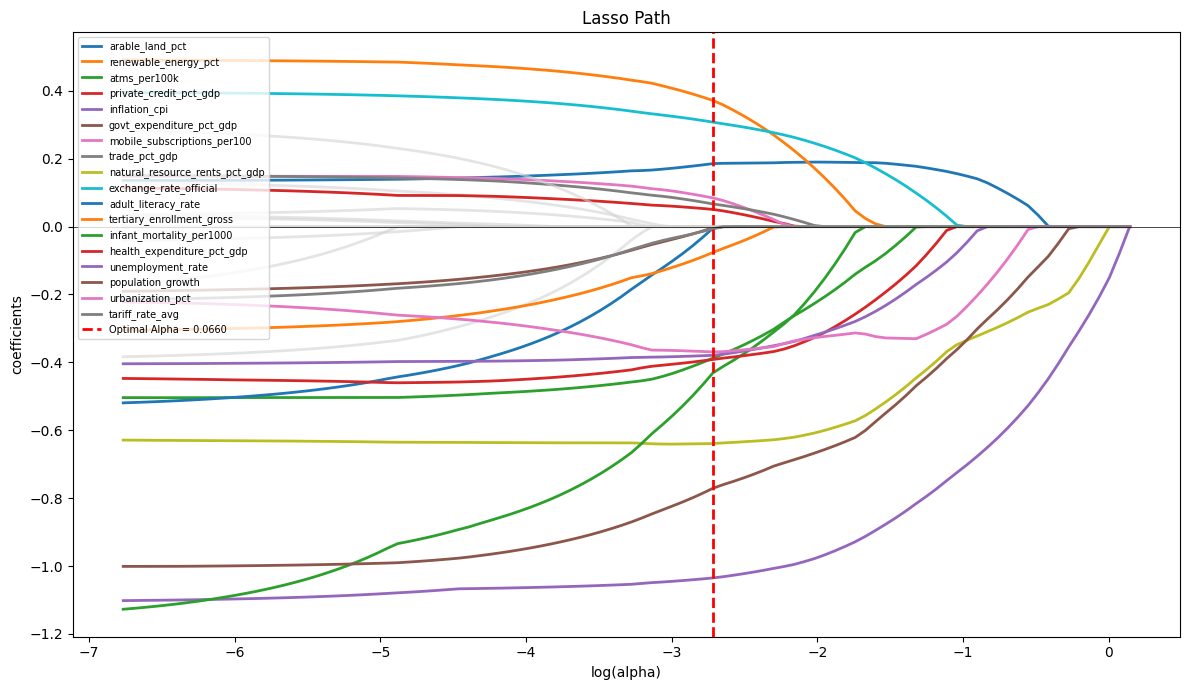

In [17]:
fig, ax = plt.subplots(figsize=(12,7))

for i in range(len(name_of_predictors)):
  if i in active_idx:
    ax.plot(np.log(alphas_path),coefs_path[i], linewidth=2, label=name_of_predictors[i])
  else:
    ax.plot(np.log(alphas_path),coefs_path[i], linewidth=2, color='lightgray', alpha=0.6)

ax.axvline(np.log(optimal_alpha), color='red', linestyle='--', linewidth=2, label=f'Optimal Alpha = {optimal_alpha:.4f}')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xlabel('log(alpha)')
ax.set_ylabel('coefficients')
ax.set_title('Lasso Path')
ax.legend(loc='upper left', fontsize=7)
plt.tight_layout()
plt.show()

In [18]:
for j in range(len(alphas_path)):
  nonzero = np.where(coefs_path[j] != 0)[0]
  if len(nonzero)>0:
    print(f"predictor 1st: {name_of_predictors[nonzero[0]]}")
    print(f"lambda: {alphas_path[j]:.4f}")
    break


predictor 1st: inflation_cpi
lambda: 1.1540


Ans:

The first entering predictor is inflation_cpi. It might be the strongest unconditional predictor of cross-country growth due to the direct inlfuence toward purchase power and creates more uncertainty.

The explanation is wrong since when life_expectancy setted zero within the Lasso model does not mean there is irrelevant with the economic growth. Instead, it indicated a conditional predictive redundancy of the prediction information of the life_expectancy factors. However, due to the strong correlation structure between WDI indexes, one representation would capture same prediction information thus setting rest of the factors as 0.

## Phase 2

In [19]:
lasso_chosen_idx = np.where(lasso_cv.coef_ != 0)[0]
select_names_predict = [name_of_predictors[i] for i in lasso_chosen_idx]

X_train_lasso = X_train_scaled[:, lasso_chosen_idx]
X_test_lasso = X_test_scaled[:, lasso_chosen_idx]

print(f"chosed_lasso_characteristics: {len(select_names_predict)}")
print(select_names_predict)

chosed_lasso_characteristics: 18
['arable_land_pct', 'renewable_energy_pct', 'atms_per100k', 'private_credit_pct_gdp', 'inflation_cpi', 'govt_expenditure_pct_gdp', 'mobile_subscriptions_per100', 'trade_pct_gdp', 'natural_resource_rents_pct_gdp', 'exchange_rate_official', 'adult_literacy_rate', 'tertiary_enrollment_gross', 'infant_mortality_per1000', 'health_expenditure_pct_gdp', 'unemployment_rate', 'population_growth', 'urbanization_pct', 'tariff_rate_avg']


In [20]:
linear_probability_model = LinearRegression()
linear_probability_model.fit(X_train_lasso, y_train_crisis)

LPM_pred_values = linear_probability_model.predict(X_test_lasso)

above_1 = np.sum(LPM_pred_values>1)

below_1 = np.sum(LPM_pred_values<0)

print(f"pred_above_1: {above_1}")
print(f"pred_below_1: {below_1}")
print(f"min_pred: {LPM_pred_values.min():.3f}")
print(f"max_pred: {LPM_pred_values.max():.3f}")


pred_above_1: 1
pred_below_1: 13
min_pred: -0.301
max_pred: 1.568


Ans: They are a fundamental problem since the it has to fall between 0 and 1. As we can see from the results, -0.301 shown zero meaning in terms of crisis prediction. In other words, it has no practical interpretation meaning. Such values would fail for the IMF to evaluate and make decisions.

### 2.2

In [21]:
logit_model = LogisticRegression(max_iter=10000, random_state=42)
logit_model.fit(X_train_lasso, y_train_crisis)

print(f"intercepts: {logit_model.intercept_}")
print(f"coefficients: {logit_model.coef_}")

intercepts: [-3.02624613]
coefficients: [[-0.95038334 -0.66644234  0.36801519 -0.07883327  0.49407513  0.13103869
   0.35611436 -0.3530879   0.72924859 -0.01478679  0.27369552 -0.07378949
   0.74339918  0.82268818  0.53242902  0.82507397  0.21187391  0.5789471 ]]


In [22]:
odds_ratios = np.exp(logit_model.coef_[0])
odds_ratio_table = pd.DataFrame({
    'Predictor': select_names_predict,
    'Odds Ratio': odds_ratios,
    'Coefficients': logit_model.coef_[0]
})

odds_ratio_table = odds_ratio_table.sort_values('Odds Ratio', key=abs, ascending=False)

print(odds_ratio_table)


                         Predictor  Odds Ratio  Coefficients
15               population_growth    2.282050      0.825074
13      health_expenditure_pct_gdp    2.276612      0.822688
12        infant_mortality_per1000    2.103072      0.743399
8   natural_resource_rents_pct_gdp    2.073522      0.729249
17                 tariff_rate_avg    1.784159      0.578947
14               unemployment_rate    1.703064      0.532429
4                    inflation_cpi    1.638982      0.494075
2                     atms_per100k    1.444864      0.368015
6      mobile_subscriptions_per100    1.427771      0.356114
10             adult_literacy_rate    1.314814      0.273696
16                urbanization_pct    1.235992      0.211874
5         govt_expenditure_pct_gdp    1.140012      0.131039
9           exchange_rate_official    0.985322     -0.014787
11       tertiary_enrollment_gross    0.928867     -0.073789
3           private_credit_pct_gdp    0.924194     -0.078833
7                    tra

In [23]:
logit_model_probabilities = logit_model.predict_proba(X_test_lasso)[:, 1]

print(f"min_prob: {logit_model_probabilities.min():.4f}")
print(f"max_prob: {logit_model_probabilities.max():.4f}")


min_prob: 0.0002
max_prob: 0.9999


Ans: The one with the largest absolute odds ratio is the population_growth, with the value of 2.28. For this case, an one standard-deviation increase in the population_growth multiplies the odds of crisis by 2.28, holding all else constant. In other words, the faster the population growth, the economic production usually not able to follow up with the speed of expansion in the population. Therefore, it causes GDP per capita to fall and is more likely to create an economic crisis.

### 2.3

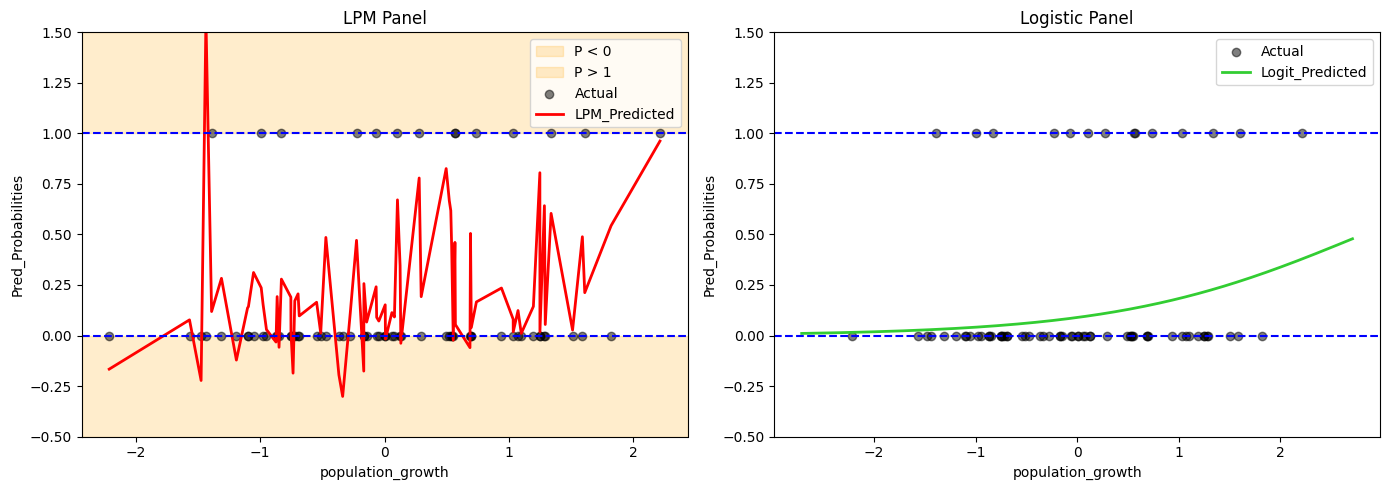

In [24]:
single_strongest_pred = 'population_growth'

strongest_selected_idx = select_names_predict.index(single_strongest_pred)

plot_x = X_test_lasso[:, strongest_selected_idx]


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].axhspan(-0.5, 0, color='orange', alpha=0.2, label='P < 0')
axes[0].axhspan(1, 1.5, color='orange', alpha=0.2, label='P > 1')
axes[0].scatter(plot_x, y_test_crisis, color='black', alpha=0.5, label='Actual')
sorting_value = np.argsort(plot_x)
axes[0].plot(plot_x[sorting_value], LPM_pred_values[sorting_value], color='red', linewidth=2, label='LPM_Predicted')
axes[0].axhline(0, color='blue', linestyle='--')
axes[0].axhline(1, color='blue', linestyle='--')
axes[0].set_xlabel(single_strongest_pred)
axes[0].set_ylabel('Pred_Probabilities')
axes[0].set_title('LPM Panel')
axes[0].legend()
axes[0].set_ylim(-0.5, 1.5)

axes[1].scatter(plot_x, y_test_crisis, color='black', alpha=0.5, label='Actual')
x_line = np.linspace(plot_x.min() - 0.5, plot_x.max()+0.5, 300)
X_line_full = np.tile(X_test_lasso.mean(axis=0), (300,1))
X_line_full[:, strongest_selected_idx] = x_line
y_line = logit_model.predict_proba(X_line_full)[:, 1]
axes[1].plot(x_line, y_line, color='limegreen', linewidth=2, label='Logit_Predicted')
axes[1].axhline(0, color='blue', linestyle='--')
axes[1].axhline(1, color='blue', linestyle='--')
axes[1].set_xlabel(single_strongest_pred)
axes[1].set_ylabel('Pred_Probabilities')
axes[1].set_title('Logistic Panel')
axes[1].legend()
axes[1].set_ylim(-0.5, 1.5)

plt.tight_layout()
plt.show()

## Phase 3

In [25]:
baseline_crisis = y_test_crisis.mean()
print(f"Base Rate Crisis: {baseline_crisis:.3f}")

Base Rate Crisis: 0.194


In [26]:
naive_predicts = np.zeros(len(y_test_crisis))
naive_predicts_of_accuracy = (naive_predicts == y_test_crisis).mean()
naive_predicts_of_recall = recall_score(y_test_crisis, naive_predicts, zero_division=0)
print(f"Naive Accuracy: {naive_predicts_of_accuracy:.3f}")
print(f"Naive Recall: {naive_predicts_of_recall:.3f}")

Naive Accuracy: 0.806
Naive Recall: 0.000


In [27]:
logit_predicts_05 = (logit_model_probabilities >= 0.5).astype(int)
logit_predicts_05_of_accuracy = (logit_predicts_05 == y_test_crisis).mean()
logit_predicts_05_of_recall = recall_score(y_test_crisis, logit_predicts_05,zero_division=0)
print(f"Logit Accuracy (0.5): {logit_predicts_05_of_accuracy:.3f}")
print(f"Logit Recall (0.5): {logit_predicts_05_of_recall:.3f}")

Logit Accuracy (0.5): 0.764
Logit Recall (0.5): 0.429


Ans: The model accuracy reached 80.6% while the recall rate is 0. In other words, it can not detect any countries that are in crisis and Division Chief would be misled if reported. Additionally, the datasets are already skewed heavily, most of the countries(80%) do not have crises. Therefore, while model did not do anything the accuracy is still high.

### 3.2

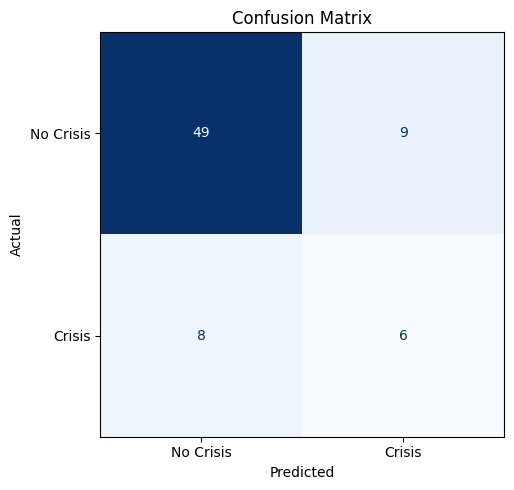

In [28]:
the_confusion_matrix = confusion_matrix(y_test_crisis, logit_predicts_05)

cm_display = ConfusionMatrixDisplay(confusion_matrix=the_confusion_matrix, display_labels=["No Crisis", 'Crisis'])
fig, ax = plt.subplots(figsize=(6, 5))
cm_display.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()


In [29]:
print(classification_report(y_test_crisis, logit_predicts_05,target_names=['No Crisis', 'Crisis']))

              precision    recall  f1-score   support

   No Crisis       0.86      0.84      0.85        58
      Crisis       0.40      0.43      0.41        14

    accuracy                           0.76        72
   macro avg       0.63      0.64      0.63        72
weighted avg       0.77      0.76      0.77        72



In [30]:
tn, fp, fn, tp = the_confusion_matrix.ravel()
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 49
False Positives: 9
False Negatives: 8
True Positives: 6


Ans: In the IMF context, False Negatives is more costly. The value of 8 for False Negatives represent a possible chance of systematic cost of sovereign default. Therefore, the Division Chief should prioritize the Recall due to the high cost of failing to report, in this case 8.

### 3.3

In [31]:
false_positive_rate, true_positive_rate, _ = roc_curve(y_test_crisis, logit_model_probabilities)
roc_val = roc_auc_score(y_test_crisis, logit_model_probabilities)

precision_vals, recall_vals, _ = precision_recall_curve(y_test_crisis, logit_model_probabilities)
precision_recall_curve_val = auc(recall_vals, precision_vals)

print(f"ROC AUC: {roc_val:.3f}")
print(f"Precision-Recall AUC: {precision_recall_curve_val:.3f}")


ROC AUC: 0.740
Precision-Recall AUC: 0.347


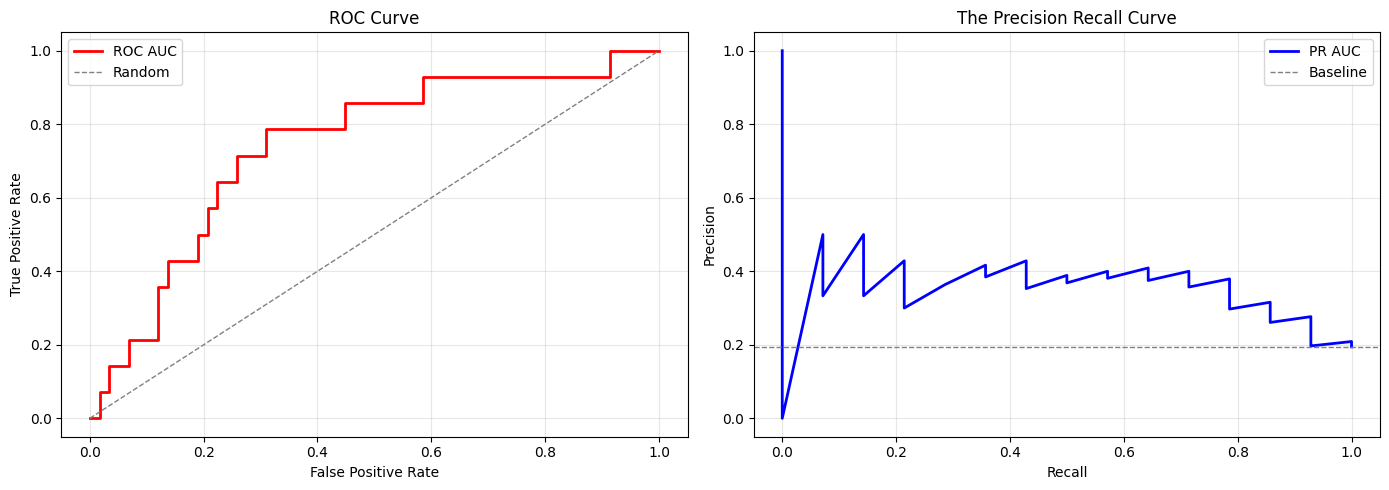

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(false_positive_rate, true_positive_rate, color='red', linewidth=2, label='ROC AUC')
axes[0].plot([0,1],[0,1], color='gray', linestyle='--', linewidth=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(recall_vals, precision_vals, color='blue', linewidth=2, label='PR AUC')
axes[1].axhline(baseline_crisis, color='gray', linestyle='--', linewidth=1, label=f'Baseline')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('The Precision Recall Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Ans: The ROC-AUC is higher than PR-AUC by 0.393. To be specific, ROC-AUC is 0.74 and PR-AUC is 0.347. The reason is due to the situation of each. In detail, 49 non-crisis countries are included within the ROC calculation, which lowers the false positive rate and performs well on the superficial side. However, PR only focus on the identification effect for the countries (14) with crisis. Therefore, it reflects the predicting ability more and real. In short, the PR curve is more informative for the IMF's crisis detection since it can effectively identify countries with crisis.

### 3.4

In [33]:
tau_threshold = np.arange(0.01, 1.00, 0.01)
recall_list, precision_list, f1_list, flagged_list = [],[],[],[]

for t in tau_threshold:
  p = (logit_model_probabilities >= t).astype(int)
  recall_list.append(recall_score(y_test_crisis, p, zero_division=0))
  precision_list.append(precision_score(y_test_crisis, p, zero_division=0))
  f1_list.append(f1_score(y_test_crisis, p, zero_division=0))
  flagged_list.append(p.sum())

tau_df = pd.DataFrame({
    'tau': tau_threshold,
    'recall': recall_list,
    'precision': precision_list,
    'f1': f1_list,
    'flagged': flagged_list
})


In [34]:
cap_df = tau_df[tau_df['flagged']<=5]
cap_best = cap_df.iloc[0]

f1_best = tau_df.iloc[tau_df['f1'].idxmax()]

print(f"capacity-constrained threshold(tau) = {cap_best['tau']:.3f}")
print(f"n_countries_flagged: {int(cap_best['flagged'])}")
print(f"Precision: {cap_best['precision']:.3f}")
print(f"Recall: {cap_best['recall']:.3f}")
print()
print(f"f1-optimal(tau): {f1_best['tau']:.3f}")
print(f"flagged_countries: {int(f1_best['flagged'])}")
print(f"F1: {f1_best}")
print(f"Precision: {f1_best['precision']:.3f}")
print(f"Recall: {f1_best['recall']:.3f}")

capacity-constrained threshold(tau) = 0.880
n_countries_flagged: 5
Precision: 0.400
Recall: 0.143

f1-optimal(tau): 0.130
flagged_countries: 25
F1: tau           0.130000
recall        0.714286
precision     0.400000
f1            0.512821
flagged      25.000000
Name: 12, dtype: float64
Precision: 0.400
Recall: 0.714


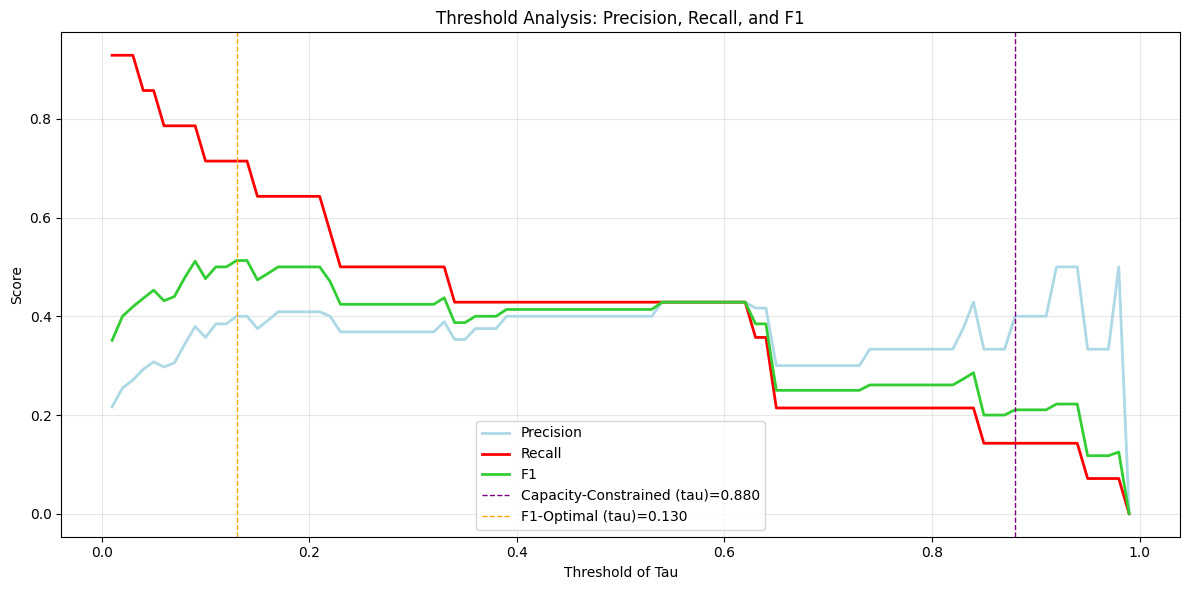

In [35]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(tau_df['tau'], tau_df['precision'] ,label='Precision', color='lightblue', linewidth=2)
ax.plot(tau_df['tau'], tau_df['recall'] ,label='Recall', color='red', linewidth=2)
ax.plot(tau_df['tau'], tau_df['f1'] ,label='F1', color='limegreen', linewidth=2)
ax.axvline(cap_best['tau'], color='purple', linestyle='--', linewidth=1, label=f"Capacity-Constrained (tau)={cap_best['tau']:.3f}")
ax.axvline(f1_best['tau'], color='orange', linestyle='--', linewidth=1, label=f"F1-Optimal (tau)={f1_best['tau']:.3f}")

ax.set_xlabel('Threshold of Tau')
ax.set_ylabel('Score')
ax.set_title('Threshold Analysis: Precision, Recall, and F1')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Ans:
The recommended threshold would be the capacity-constrained threshold(tau). To be specific, the value is 0.88 with 5 flagging countries. The detailed performance for this threshold is the identification of 2 countries within the 14 crisis-countries, the recall-rate of 14.3%. Under comparison, f1-optimal(tau) has a value of 0.13 and its recall rate reached 71.4%, even though it identified 10 crisis-countries, it required a flagging of 25 countries which exceeded the 5 capacity constraints. Under such constraints, the trade-off for choosing capacity-constrained threshold would be most of the crisis countries would be missing out. Therefore, IMF should utilize methods like task-capacity increasing to sort out the price of resource constraints.

## Phase 4 AI


### 4.1

[Prep] You are an expert Python data scientist specializing in Lasso regularization and Bootstrap resampling methods.

[Request] I am working on an IMF sovereign risk project. I have already used LassoCV to select WDI indicators, but I suspect the selection is unstable due to high correlation among predictors. Please write a Python script that:
1. Draws 200 bootstrap resamples with replacement from the training data
2. Fits LassoCV(cv=5) on each resample and records which features have non-zero coefficients
3. Computes selection frequency for each predictor: the fraction of 200 samples where it was selected
4. Plots a horizontal bar chart ranked by selection frequency, with a vertical reference line at 50%
Use variable names: X_train_scaled, y_train, name_of_predictors

[Iterate] Use np.random.seed(42) for reproducibility. Skip any bootstrap sample where only one class exists.

[Mechanism Check] Add inline comments explaining why bootstrap resampling measures feature selection stability.

[Evaluate] After the chart, identify which features are stable (>80%) and which are fragile (<30%).

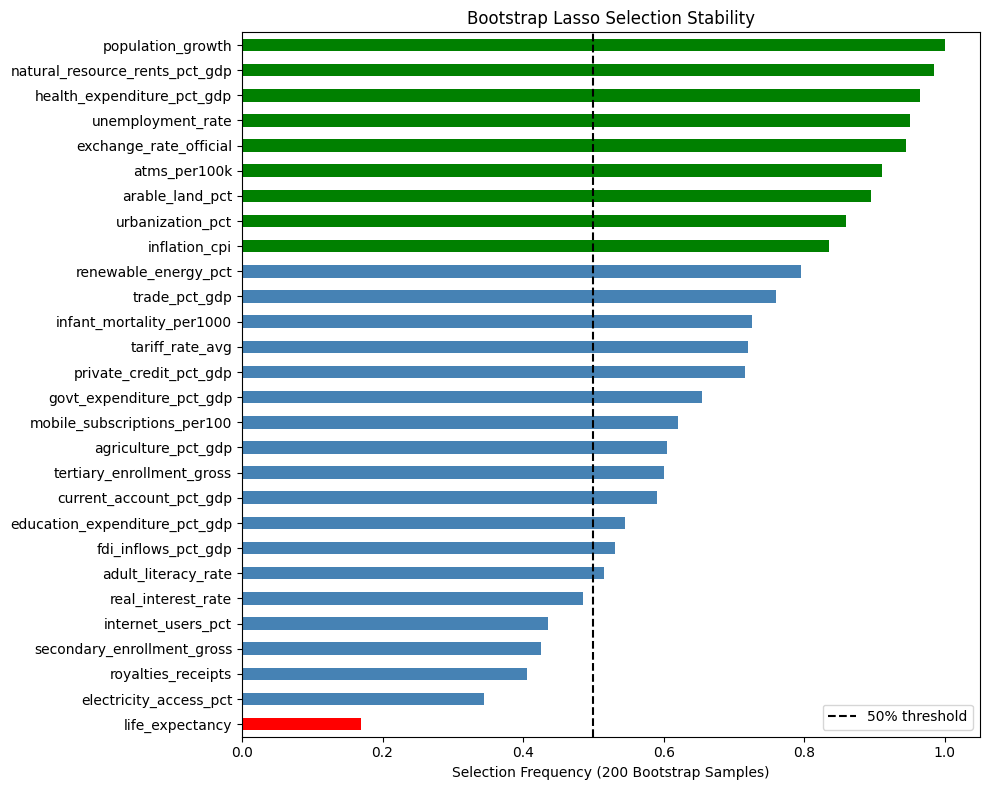

Stable features (>80%): ['arable_land_pct', 'atms_per100k', 'inflation_cpi', 'natural_resource_rents_pct_gdp', 'exchange_rate_official', 'health_expenditure_pct_gdp', 'unemployment_rate', 'population_growth', 'urbanization_pct']
Fragile features (<30%): ['life_expectancy']


In [36]:
np.random.seed(42)
n_boots = 200
select_count = {name: 0 for name in name_of_predictors}

for b in range(n_boots):
    idx = np.random.choice(len(X_train_scaled), size=len(X_train_scaled), replace=True)
    X_boot = X_train_scaled[idx]
    y_boot = y_train[idx]
    if len(np.unique(y_boot)) < 2:
        continue
    lasso_boot = LassoCV(cv=5, max_iter=10000, random_state=42)
    lasso_boot.fit(X_boot, y_boot)
    nonzero = np.where(lasso_boot.coef_ != 0)[0]
    for i in nonzero:
        select_count[name_of_predictors[i]] += 1

select_freq = {k: v / n_boots for k, v in select_count.items()}
freq_series = pd.Series(select_freq).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['green' if v > 0.8 else ('red' if v < 0.3 else 'steelblue')
          for v in freq_series.values]
freq_series.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='50% threshold')
ax.set_xlabel('Selection Frequency (200 Bootstrap Samples)')
ax.set_title('Bootstrap Lasso Selection Stability')
ax.legend()
plt.tight_layout()
plt.show()

stable = [k for k, v in select_freq.items() if v > 0.8]
fragile = [k for k, v in select_freq.items() if v < 0.3]
print(f"Stable features (>80%): {stable}")
print(f"Fragile features (<30%): {fragile}")

AI Response: The stable features (selection frequency >80%) include population_growth, natural_resource_rents_pct_gdp, health_expenditure_pct_gdp, unemployment_rate, exchange_rate_official, atms_per100k, arable_land_pct, urbanization_pct, and inflation_cpi, indicating that these variables maintain a robust and consistent predictive relationship with GDP growth regardless of which countries are included in the sample. The only fragile feature (selection frequency <30%) is life_expectancy, which does not mean it is economically irrelevant — rather, it reflects the high correlation structure among WDI indicators, where Lasso randomly picks one representative variable from a group of correlated predictors, causing individual selection frequencies to drop.

### 4.2

[Prep] You are an expert Python data scientist specializing in cost-sensitive machine learning and threshold optimization.

[Request] I am working on an IMF sovereign risk project. A missed crisis (FN) costs $50 billion and a false alarm (FP) costs $2 million. Please write a Python script that:
1. Sweeps thresholds from 0.01 to 0.99 in steps of 0.01
2. At each threshold, computes total expected cost: FN × 50,000,000,000 + FP × 2,000,000
3. Plots the expected cost curve as a function of tau
4. Identifies and annotates the cost-minimizing threshold
Use variable names: logit_model_probabilities, y_test_crisis

[Iterate] Make the y-axis display in billions of dollars. Annotate the minimum cost point clearly on the plot.

[Mechanism Check] Add inline comments explaining why the asymmetric cost structure pushes the optimal threshold lower.

[Evaluate] Compare the cost-minimizing threshold to the F1-optimal and capacity-constrained thresholds.

Cost-minimizing threshold: tau = 0.03
Expected total cost: $50.07B


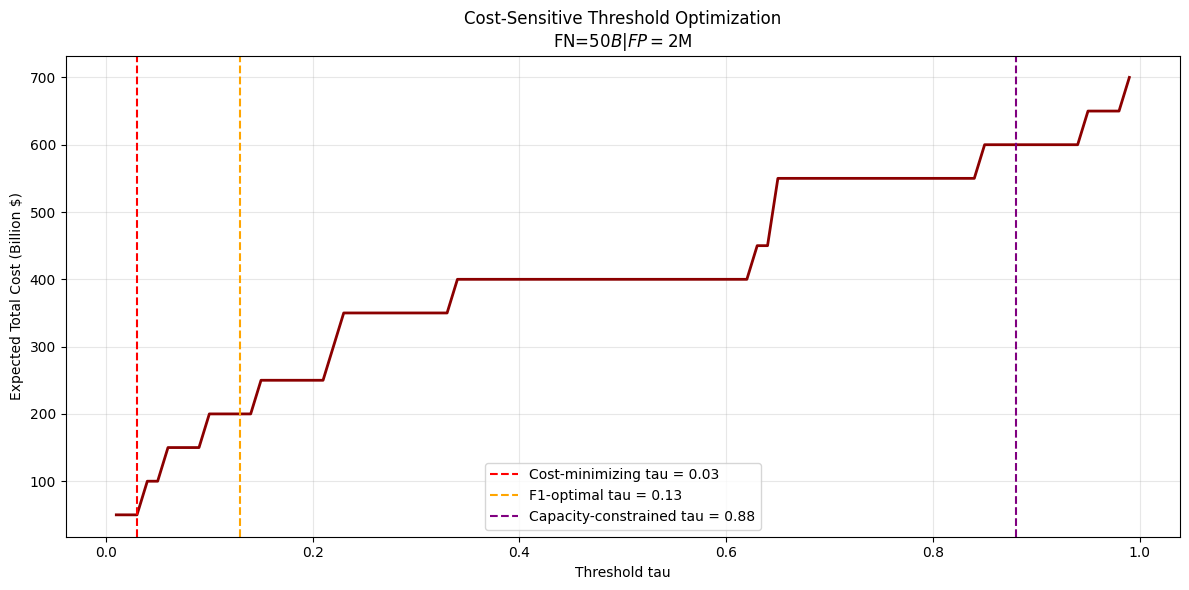

In [37]:
COST_FN = 50_000_000_000
COST_FP = 2_000_000

tau_range2 = np.arange(0.01, 1.00, 0.01)
cost_list = []

for t in tau_range2:
    p = (logit_model_probabilities >= t).astype(int)
    fn = ((p == 0) & (y_test_crisis == 1)).sum()
    fp = ((p == 1) & (y_test_crisis == 0)).sum()
    total = fn * COST_FN + fp * COST_FP
    cost_list.append(total)

cost_df = pd.DataFrame({'tau': tau_range2, 'cost': cost_list})
best_cost = cost_df.loc[cost_df['cost'].idxmin()]

print(f"Cost-minimizing threshold: tau = {best_cost['tau']:.2f}")
print(f"Expected total cost: ${best_cost['cost']/1e9:.2f}B")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cost_df['tau'], cost_df['cost']/1e9, color='darkred', lw=2)
ax.axvline(best_cost['tau'], color='red', linestyle='--', lw=1.5,
           label=f"Cost-minimizing tau = {best_cost['tau']:.2f}")
ax.axvline(f1_best['tau'], color='orange', linestyle='--', lw=1.5,
           label=f"F1-optimal tau = {f1_best['tau']:.2f}")
ax.axvline(cap_best['tau'], color='purple', linestyle='--', lw=1.5,
           label=f"Capacity-constrained tau = {cap_best['tau']:.2f}")
ax.set_xlabel('Threshold tau')
ax.set_ylabel('Expected Total Cost (Billion $)')
ax.set_title('Cost-Sensitive Threshold Optimization\nFN=$50B | FP=$2M')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

AI response: The cost-minimizing threshold (τ = 0.03) is significantly lower than both the F1-optimal threshold (τ = 0.13) and the capacity-constrained threshold (τ = 0.88), because the asymmetric cost structure — where a missed crisis costs $50 billion versus only $2 million for a false alarm — pushes the optimal operating point toward extreme aggressiveness. The F1-optimal threshold treats false positives and false negatives equally, ignoring the real-world cost imbalance, which is why it sits higher. In practice, the cost-minimizing threshold should be recommended, as preventing sovereign default is the IMF's core mission and the financial consequences of a missed crisis far outweigh the cost of multiple false alarm missions.